In [1]:
import numpy as np
import matplotlib.pyplot as plt
from reg_utils import sigmoid, relu, plot_decision_boundary, initialize_parameters, load_2D_dataset, predict_dec
from reg_utils import compute_cost, predict, forward_propagation, backward_propagation, update_parameters
import sklearn
import sklearn.datasets
import scipy.io


plt.rcParams['figure.figsize'] = (7.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

/Users/thoshithkumar/Desktop/deeplearning/improving-deep-learning/reg_utils.py:85: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(parameters['W' + str(l)].shape == layer_dims[l], layer_dims[l-1])
/Users/thoshithkumar/Desktop/deeplearning/improving-deep-learning/reg_utils.py:86: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(parameters['W' + str(l)].shape == layer_dims[l], 1)


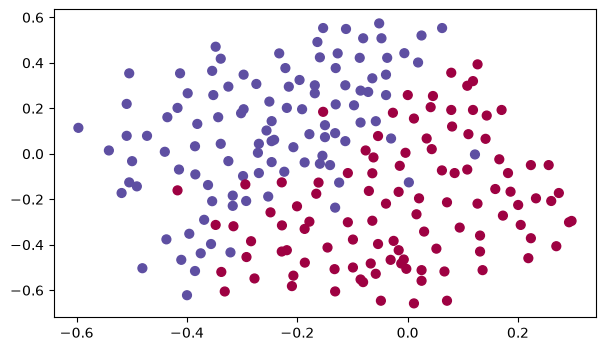

In [ ]:
train_X, train_Y, test_X, test_Y = load_2D_dataset()

In [5]:
def model(X,Y, learning_rate = 0.3, num_iterations = 30000, print_cost = True,lambd=0,keep_prob = 1):
    
    costs = []
    layers_dims = [X.shape[0], 20,3,1]
    parameters = initialize_parameters_deep(layers_dims)
    
    for i in range(num_iterations):
        if keep_prob == 1:
            A3, cache = forward_propagation(X, parameters)
        elif keep_prob < 1:
            A3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)
        if lambd == 0:
            cost = compute_cost(A3,Y)
        elif lambd > 0:
            cost = compute_cost_with_regularization(A3, Y, parameters, lambd)
        if lambd == 0 and keep_prob == 1:
            grads = backward_propagation(X,Y,cache)
        elif lambd > 0:
            grads = backward_propagation_with_regularization(X,Y,cache, lambd)
        elif keep_prob < 1:
            grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            costs.append(cost)
            if print_cost == True:
                print(f"cost after iterations {i}: {cost}")

    return parameters
        